Pretrained models:

- EfficientNet
- ResNet50
- DenseNet-121
- Vision Transformers (ViT)

In [1]:
# Imports
import torch
from torchvision.models import efficientnet_b0, resnet50, densenet121, vit_b_16
from torchvision import transforms
from collections import OrderedDict
from PIL import Image
import json
import os
import numpy as np


In [2]:
# Variables
dir_path = 'pretrained/'
num_classes = 1081  # Number of classes for the Pl@ntNet-300K dataset

In [3]:
# EfficientNet
EN_checkpoint_path = 'efficientnet_b0_weights_best_acc.tar'
EN_model = efficientnet_b0(num_classes=num_classes)
EN_model = torch.nn.Sequential(*(list(EN_model.children())[:-1]))  # Keep all layers except the last one

# Load checkpoint
try:
    EN_checkpoint = torch.load(dir_path + EN_checkpoint_path, map_location='cpu')
    EN_state_dict = EN_checkpoint.get('state_dict', EN_checkpoint)  # Use 'state_dict' if it exists, otherwise the checkpoint itself

    # Adjust state_dict keys if necessary (e.g., remove 'module.' prefix)
    EN_new_state_dict = OrderedDict()
    for k, v in EN_state_dict.items():
        EN_new_key = k.replace('module.', '')  # Adjust this as needed based on the key inspection
        EN_new_state_dict[EN_new_key] = v

    # Load the adjusted state_dict into the model
    EN_model.load_state_dict(EN_new_state_dict, strict=False)
    print("Checkpoint loaded successfully.")
except Exception as e:
    print(f"Error loading checkpoint: {e}")
    exit(1)

Checkpoint loaded successfully.


C:\Users\Lars\AppData\Local\Temp\ipykernel_27752\2186689051.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  EN_checkpoint = torch.load(dir_path + EN_checkpoint_path, map

In [4]:
# ResNet50
RN_checkpoint_path = 'resnet50_weights_best_acc.tar'
RN_model = resnet50(num_classes=num_classes)
RN_model = torch.nn.Sequential(*(list(RN_model.children())[:-1]))  # Keep all layers except the last one

# Load checkpoint
try:
    RN_checkpoint = torch.load(dir_path + RN_checkpoint_path, map_location='cpu')
    RN_state_dict = RN_checkpoint.get('state_dict', RN_checkpoint)  # Use 'state_dict' if it exists, otherwise the checkpoint itself

    # Adjust state_dict keys if necessary (e.g., remove 'module.' prefix)
    RN_new_state_dict = OrderedDict()
    for k, v in RN_state_dict.items():
        RN_new_key = k.replace('module.', '')  # Adjust this as needed based on the key inspection
        RN_new_state_dict[RN_new_key] = v

    # Load the adjusted state_dict into the model
    RN_model.load_state_dict(RN_new_state_dict, strict=False)
    print("Checkpoint loaded successfully.")
except Exception as e:
    print(f"Error loading checkpoint: {e}")
    exit(1)


Checkpoint loaded successfully.


C:\Users\Lars\AppData\Local\Temp\ipykernel_27752\3824412445.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  RN_checkpoint = torch.load(dir_path + RN_checkpoint_path, map

In [5]:
# DenseNet-121
DN_checkpoint_path = 'densenet121_weights_best_acc.tar'
DN_model = densenet121(num_classes=num_classes)
DN_model = torch.nn.Sequential(*(list(DN_model.children())[:-1]))  # Keep all layers except the last one

# Load checkpoint
try:
    DN_checkpoint = torch.load(dir_path + DN_checkpoint_path, map_location='cpu')
    DN_state_dict = RN_checkpoint.get('state_dict', DN_checkpoint)  # Use 'state_dict' if it exists, otherwise the checkpoint itself

    # Adjust state_dict keys if necessary (e.g., remove 'module.' prefix)
    DN_new_state_dict = OrderedDict()
    for k, v in DN_state_dict.items():
        DN_new_key = k.replace('module.', '')  # Adjust this as needed based on the key inspection
        DN_new_state_dict[DN_new_key] = v

    # Load the adjusted state_dict into the model
    DN_model.load_state_dict(DN_new_state_dict, strict=False)
    print("Checkpoint loaded successfully.")
except Exception as e:
    print(f"Error loading checkpoint: {e}")
    exit(1)


Checkpoint loaded successfully.


C:\Users\Lars\AppData\Local\Temp\ipykernel_27752\2410851860.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  DN_checkpoint = torch.load(dir_path + DN_checkpoint_path, map

In [6]:
# ViT
ViT_checkpoint_path = 'vit_base_patch16_224_weights_best_acc.tar'
ViT_model = vit_b_16(num_classes=num_classes)
ViT_model = torch.nn.Sequential(*(list(ViT_model.children())[:-1]))  # Keep all layers except the last one

# Load checkpoint
try:
    ViT_checkpoint = torch.load(dir_path + ViT_checkpoint_path, map_location='cpu')
    ViT_state_dict = ViT_checkpoint.get('state_dict', ViT_checkpoint)  # Use 'state_dict' if it exists, otherwise the checkpoint itself

    # Adjust state_dict keys if necessary (e.g., remove 'module.' prefix)
    ViT_new_state_dict = OrderedDict()
    for k, v in ViT_state_dict.items():
        ViT_new_key = k.replace('module.', '')  # Adjust this as needed based on the key inspection
        ViT_new_state_dict[ViT_new_key] = v

    # Load the adjusted state_dict into the model
    ViT_model.load_state_dict(ViT_new_state_dict, strict=False)
    print("Checkpoint loaded successfully.")
except Exception as e:
    print(f"Error loading checkpoint: {e}")
    exit(1)

Checkpoint loaded successfully.


C:\Users\Lars\AppData\Local\Temp\ipykernel_27752\3516094736.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ViT_checkpoint = torch.load(dir_path + ViT_checkpoint_path, m

Extract features and preprocess images

In [7]:
def load_class_labels(label_path):
    """
    Load class labels from a JSON file.
    """
    with open(label_path, 'r') as f:
        labels = json.load(f)  # Assuming the labels are stored in a list format
    return labels


def extract_features(model, input_tensor):
    """
    Extract features from input tensor using encoder part of model
    """
    model.eval()
    with torch.no_grad():
        features = model(input_tensor)  # Get features from encoder
    return features


def preprocess_image(image):
    """
    Preprocess input image for pretrained models
    """
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    return preprocess(image)

In [ ]:
# Load class labels (if needed for a specific task)
label_path = "plantnet300K_species_names.json"
class_labels = load_class_labels(label_path)

# Load and preprocess the image
dir_path = "data/frames/"
files = os.listdir(dir_path)
print(f"Total amount of frames: {len(files)}")

json_file_path = "embeddings.json"
json_data = []

embeddings = []

model = ViT_model

for i, frame in enumerate(files):
    frame = Image.open(dir_path + frame)  # Load the image
    preprocessed_image = preprocess_image(frame)  # Preprocess the image
    input_tensor = preprocessed_image.unsqueeze(0)  # Shape (1, 3, 224, 224) so only 1 images goes trough the network
    features = extract_features(model, input_tensor)
    print(len(features.cpu().numpy().flatten()))
    
    # write to json
    data = {
        "filename": f"frame{i}.jpg",
        "feature": features.cpu().numpy().flatten().tolist()
    }
    json_data.append(data)
    
    embeddings.append(features.cpu().numpy().flatten())

with open(json_file_path, 'w') as json_file:
    json.dump(json_data, json_file, indent=4)  # Write with pretty printing


embeddings = np.array(embeddings)

Total amount of frames: 84
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176
50176


In [9]:
def load_img(img_path, target_size=None):
    """Load and resize an image."""
    img = Image.open(img_path)
    if target_size:
        img = img.resize(target_size)
    return np.array(img)  # Convert to a numpy array for matplotlib

In [10]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import numpy as np

def visualize_embeddings(embeddings):
    # Create a scatter plot
    plt.figure(figsize=(10, 8))

    # Loop through each point and add the corresponding thumbnail
    for idx, point in enumerate(embeddings):
        x, y = point[0], point[1]
        
        plt.scatter(x, y, alpha=0)  # Hide the original points
        
        # Load and create thumbnail for the image
        img = load_img(os.path.join(dir_path, files[idx]), target_size=(50, 50))  # Resize thumbnail
        imagebox = OffsetImage(img, zoom=0.8)  # Adjust zoom as needed
        
        # Create an annotation box with the thumbnail
        ab = AnnotationBbox(imagebox, (x, y), frameon=False, pad=0.1)
        
        # Add the annotation box to the plot
        plt.gca().add_artist(ab)

    plt.title("Image Embeddings")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.autoscale(True)
    plt.grid()
    plt.show()


Data representation

For small datasets, following methods are most recommended:

- t-SNE
- UMAP
- PCA
- Isomap

In [11]:
# t-SNE
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=25, random_state=42)

# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

# Isomap
from sklearn.manifold import Isomap
isomap = Isomap(n_components=2)

In [12]:
tsne_result = tsne.fit_transform(embeddings)
pca_results = pca.fit_transform(embeddings)
isomap_results = isomap.fit_transform(embeddings)

c:\Users\Lars\Documents\%KUL\%Master\%Thesis\Github\Lars\.venv\Lib\site-packages\threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


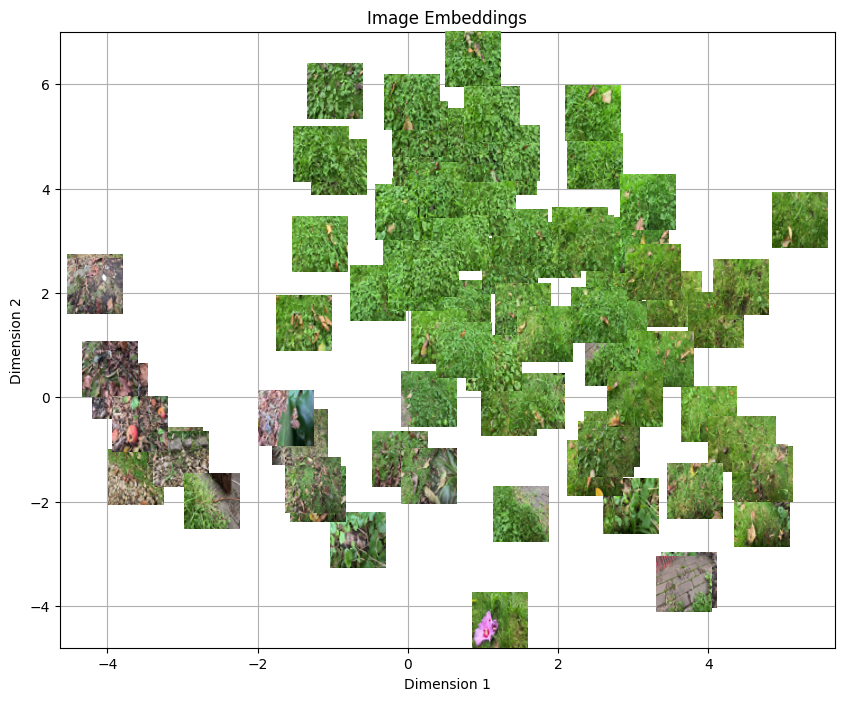

In [13]:
visualize_embeddings(tsne_result)

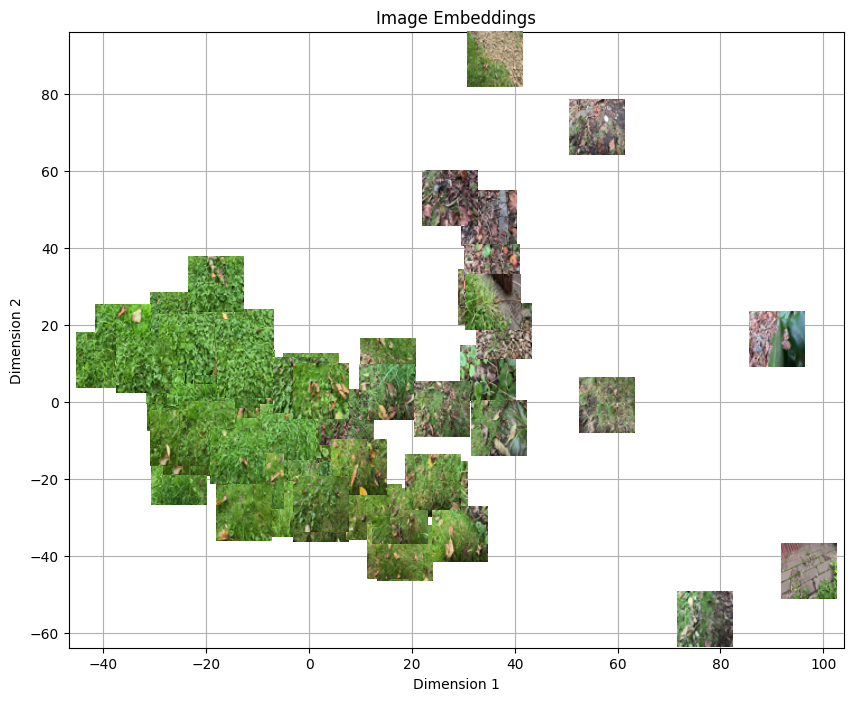

In [14]:
visualize_embeddings(pca_results)

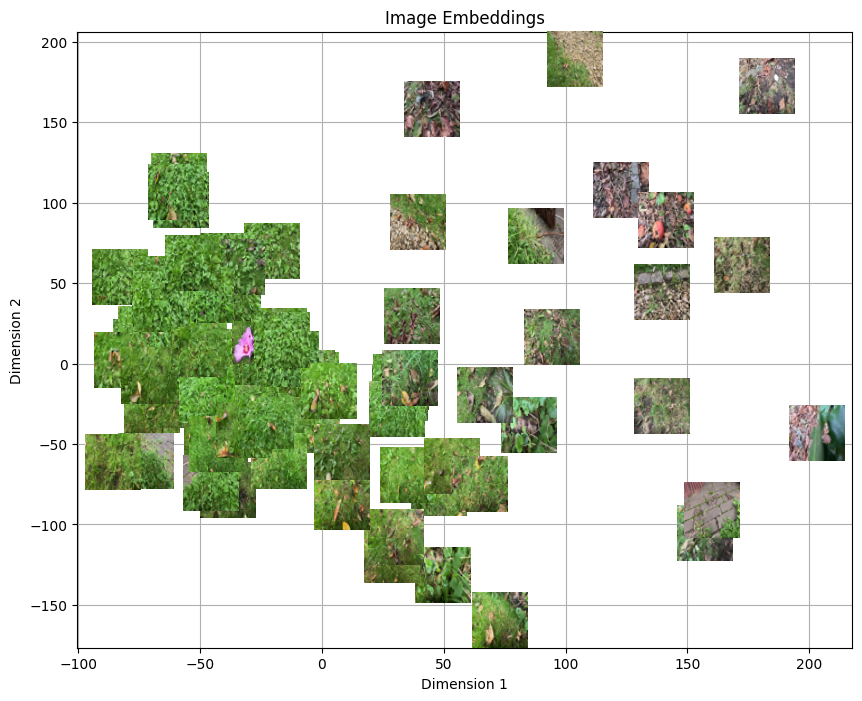

In [15]:
visualize_embeddings(isomap_results)